# Unsupervised Anomaly Detection — Early Warning System
### Business Case 4

---

## Objective

Build an **Early Warning System** capable of detecting anomalous market periods 
(*risk-off* regimes) using **unsupervised learning models**. These models do not use 
labels during training and instead learn to identify anomalies as observations that 
structurally deviate from normal market behavior.

The dataset contains weekly financial data from **January 18, 2000** to 
**April 20, 2021** (1,110 observations, 42 features), including equity indices, 
interest rates, currencies, commodities, and the VIX. A binary target variable `Y` 
is available for evaluation purposes (`0 = normal`, `1 = anomaly/risk-off`). 
Approximately **21.4%** of the observations are classified as anomalies.

## Pipeline

1. Load the dataset and separate features from labels
2. Apply stationarity transformations
3. Shuffle the data, perform train/CV/test splits, and standardize features
4. Train baseline models:
   - Isolation Forest
   - One-Class SVM
   - Local Outlier Factor (LOF)
   - Gaussian Mixture Model (GMM)
5. Train additional models:
   - COPOD
   - ECOD
   - PCA Reconstruction Error
   - Histogram-Based Outlier Score (HBOS)
6. Optimize hyperparameters using Optuna
7. Perform model analysis:
   - ROC curves
   - Feature importance analysis
   - Temporal analysis of detected anomalies
8. Summarize findings and provide a pros/cons comparison table

## 1. Data Loading

Load the dataset from the Excel file, set the `Date` column as the time index,
and separate the feature matrix `X` from the target variable `y`.

- `X` contains the 42 financial variables
- `y` is the binary label vector (`0 = normal`, `1 = risk-off/anomaly`)

In [38]:
from pathlib import Path
import pandas as pd

path = Path() / "Dataset4_EWS.xlsx"

data = pd.read_excel(path, sheet_name='Markets')
data = data.set_index("Data")
data.index = pd.to_datetime(data.index)
data = data.sort_index()

X = data.drop('Y', axis=1)
y = data['Y'].values

## 2. Stationarity Transformation

Financial time series are typically **non-stationary**: prices tend to grow over time,
and their mean and variance change. A model trained on price levels from 2005 would
not generalize properly to market conditions in 2020.

We apply three different transformations depending on the variable type:

| Type | Transformation | Rationale |
|---|---|---|
| Equity indices and currencies (23 features) | Log difference: log(Pₜ) − log(Pₜ₋₁) | Always positive, multiplicative growth dynamics |
| Interest rates (18 features) | First difference: rₜ − rₜ₋₁ | Can be negative, therefore log transformation is not applicable |
| ECSURPUS (1 feature) | As-is | Already stationary by construction |

> The transformation does not estimate any global parameters—each value depends
> only on the previous observation. Therefore, it does not introduce data leakage
> and can be safely applied before the train/test split. Since `np.diff()` removes
> the first observation, the target vector `y` is shortened accordingly, from 1,111
> to **1,110 observations**.

In [39]:
import numpy as np

# Make data stationary based on variable type
# So w define lists of variables by type
indices_currencies = [col for col in X.columns if col in [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]]

interest_rates = [col for col in X.columns if col in [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]]

# Create a new dataframe for stationary data
stationary_df = pd.DataFrame(index=X.index[1:])

# Apply log-differences to indices and currencies (always positive)
for col in indices_currencies:
    if col in X.columns:
        stationary_df[col] = np.diff(np.log(X[col]))

# Apply first differences to interest rates (can be negative or very close to 0)
for col in interest_rates:
    if col in X.columns:
        stationary_df[col] = np.diff(X[col])

# Keep Bloomberg Economic US Surprise Index as is (already stationary)
if 'ECSURPUS' in X.columns:
    stationary_df['ECSURPUS'] = X['ECSURPUS'].values[1:]

# Adjust the response variable to match the new data length
if y is not None:
    y_stationary = y[1:]
else:
    y_stationary = None


## 3. Data Splitting, Shuffling, and Standardization

### Shuffling

The data is shuffled before splitting in order to break the temporal
autocorrelation typical of financial time series. This results in a more
robust evaluation and makes the anomaly detection task more challenging
for the models.

### Splitting Strategy

Unsupervised anomaly detection models are trained **only on normal observations**—
they never see anomalies during training. The split is therefore asymmetric to
ensure that the evaluation sets contain enough anomalies for statistically
reliable performance metrics.

| Set | Composition | Observations |
|---|---|---|
| `X_train` | 80% of the 873 normal observations | 698 normal, 0 anomalies |
| `X_cross_val` | 10% of normal observations + 50% of the 237 anomalies | 87 normal + 118 anomalies = 205 |
| `X_test` | 10% of normal observations + 50% of the anomalies | 88 normal + 119 anomalies = 207 |

### Standardization

The `StandardScaler` is fitted **exclusively on `X_train`** and then applied
to the cross-validation and test sets. Fitting it on the entire dataset would
transfer information from the test set into the training process, introducing
data leakage.

### Contamination

The contamination rate is estimated from the proportion of anomalies in the
cross-validation set and capped at 0.5 to avoid degenerate model behavior:

```python

In [40]:
# Step 1: shuffle and split data into training, validation, and test sets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Convert to numpy arrays for easier manipulation
X = stationary_df.values
y = y_stationary

# Step 1: Creating training/cross-validation/test set with reshuffling

# Reshuffle the data (this will break down autocorrelation)
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

# Separate normal and anomalous examples
X_normal = X_shuffled[y_shuffled == 0]
X_anomaly = X_shuffled[y_shuffled == 1]

# Calculate sizes for each set
n_normal = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]

# Training set: 80% of normal examples
train_size = int(0.8 * n_normal)
X_train = X_normal[:train_size]

# Cross-validation set: 10% of normal examples and 50% of anomalies
cv_normal_size = int(0.1 * n_normal)
cv_anomaly_size = int(0.5 * n_anomaly)
X_cv_normal = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly = X_anomaly[:cv_anomaly_size]
X_cross_val = np.vstack((X_cv_normal, X_cv_anomaly))
y_cross_val = np.hstack((np.zeros(cv_normal_size), np.ones(cv_anomaly_size)))

# Test set: 10% of normal examples and 50% of anomalies
X_test_normal = X_normal[train_size + cv_normal_size:]
X_test_anomaly = X_anomaly[cv_anomaly_size:]
X_test = np.vstack((X_test_normal, X_test_anomaly))
y_test = np.hstack((np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))))

# We'll standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_cross_val = scaler.transform(X_cross_val)
X_test = scaler.transform(X_test)

print(f"Anomaly rate nel dataset: {np.mean(y_stationary)*100:.1f}%")
print(f"Anomalie totali: {int(np.sum(y_stationary))}")
print(f"\nX_train:     {X_train.shape} — normali: {X_train.shape[0]}")
print(f"X_cross_val: {X_cross_val.shape} — normali: {cv_normal_size}, anomalie: {cv_anomaly_size}")
print(f"X_test:      {X_test.shape} — normali: {len(X_test_normal)}, anomalie: {len(X_test_anomaly)}")


Anomaly rate nel dataset: 21.4%
Anomalie totali: 237

X_train:     (698, 42) — normali: 698
X_cross_val: (205, 42) — normali: 87, anomalie: 118
X_test:      (207, 42) — normali: 88, anomalie: 119


## 4. Unsupervised Models

All models follow the same evaluation protocol:

- **Training** on `X_train` (698 observations, normal data only)
- **Tuning** of the contamination parameter or decision threshold on `X_cross_val`
- **Final evaluation** on `X_test` using the following metrics: Precision, Recall, F1, and AUC

### Evaluation Metrics

- **Precision** — among all observations classified as anomalies, how many were actually anomalous
- **Recall** — among all true anomalies in the test set, how many were successfully detected
- **F1 Score** — harmonic mean of Precision and Recall; the primary metric used for model comparison
- **AUC** — the model's ability to separate normal observations from anomalies regardless of the chosen threshold

> In a **risk management** context, Recall is often the most critical metric:
> missing a market crisis is typically more costly than generating a false alarm.

### 4.1 Isolation Forest *(Reference Model)*

**Concept:** anomalies are easier to isolate than normal observations.
The algorithm builds an ensemble of decision trees using random splits.
Because anomalous observations tend to lie in sparse regions of the feature space,
they can be isolated with only a few splits. Normal observations, being surrounded
by many similar points, typically require a larger number of splits before they
become isolated.

In [41]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Contamination of CV set capped at 0.5
contamination = min(np.mean(y_cross_val), 0.5)
print(f"Contamination: {contamination:.4f}")

# Isolation Forest
iso_model = IsolationForest(contamination=contamination, random_state=42)
iso_model.fit(X_train)

iso_pred  = (iso_model.predict(X_test) == -1).astype(int)
iso_score = -iso_model.score_samples(X_test)

precision = precision_score(y_test, iso_pred, zero_division=0)
recall    = recall_score(y_test, iso_pred, zero_division=0)
f1        = f1_score(y_test, iso_pred, zero_division=0)
auc       = roc_auc_score(y_test, iso_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df = pd.DataFrame(columns=['Model','Precision','Recall','F1','AUC'])
results_df.loc[len(results_df)] = ['Isolation Forest', precision, recall, f1, auc]

Contamination: 0.5000
Precision: 0.6838
Recall:    0.7815
F1:        0.7294
AUC:       0.6975


### 4.2 One-Class SVM *(Reference Model)*

**Concept:** the model learns a decision boundary in a kernel-transformed feature
space that encloses the majority of the normal training observations. Points
falling outside this boundary are classified as anomalies.

The `nu` parameter represents an upper bound on the fraction of training errors
and is conceptually equivalent to the contamination rate. It is therefore set
accordingly and clipped to the interval `(0.01, 0.99)` to satisfy the parameter's
constraints.

**Kernel:** RBF with `gamma='auto'` — capable of capturing nonlinear structures.  
**Strength:** flexible and effective at modeling complex decision boundaries.  
**Limitation:** computationally expensive on large datasets.

In [42]:
from sklearn.svm import OneClassSVM

nu = min(max(0.01, contamination), 0.99)
print(f"Nu: {nu:.4f}")

ocsvm_model = OneClassSVM(gamma='auto', nu=nu)
ocsvm_model.fit(X_train)

ocsvm_pred  = (ocsvm_model.predict(X_test) == -1).astype(int)
ocsvm_score = -ocsvm_model.decision_function(X_test)

precision = precision_score(y_test, ocsvm_pred, zero_division=0)
recall    = recall_score(y_test, ocsvm_pred, zero_division=0)
f1        = f1_score(y_test, ocsvm_pred, zero_division=0)
auc       = roc_auc_score(y_test, ocsvm_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['One-Class SVM', precision, recall, f1, auc]

Nu: 0.5000
Precision: 0.6643
Recall:    0.7983
F1:        0.7252
AUC:       0.7242


### 4.3 Local Outlier Factor (LOF) *(Reference Model)*

**Concept:** the algorithm compares the local density of each observation with
the density of its `k` nearest neighbors. If a point lies in a region that is
significantly less dense than the surrounding observations, it is classified
as an anomaly.

LOF is particularly effective at detecting **local anomalies**, i.e., observations
that may appear normal globally but are unusual relative to their immediate
neighborhood.

In [43]:
from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
lof_model.fit(X_train)

lof_pred  = (lof_model.predict(X_test) == -1).astype(int)
lof_score = -lof_model.decision_function(X_test)

precision = precision_score(y_test, lof_pred, zero_division=0)
recall    = recall_score(y_test, lof_pred, zero_division=0)
f1        = f1_score(y_test, lof_pred, zero_division=0)
auc       = roc_auc_score(y_test, lof_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['LOF', precision, recall, f1, auc]

Precision: 0.6735
Recall:    0.8319
F1:        0.7444
AUC:       0.7420


### 4.4 Gaussian Mixture Model (GMM) — 2 Components *(Reference Model)*

**Concept:** the data is modeled as a mixture of two Gaussian distributions.
An observation is considered anomalous if it has a low log-likelihood under
the fitted model, meaning that it lies in a region of the feature space that
is unlikely according to the learned Gaussian components.

The choice of **two components** is financially motivated: markets are often
characterized by two distinct regimes:

- **Risk-on:** low volatility and relatively moderate correlations
- **Risk-off:** elevated volatility, stronger correlations, and a flight toward safe-haven assets

**Anomaly score:** negative log-likelihood — higher values indicate a higher degree of abnormality.  
**Threshold:** determined on the cross-validation set using the contamination percentile.

> **Improvement over the original notebook:** the original implementation
> estimated the threshold directly from the test-set scores, introducing
> data leakage. In this version, the threshold is correctly estimated using
> `X_cross_val` only.

In [44]:
from sklearn.mixture import GaussianMixture

gmm_model = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_model.fit(X_train)

# score_samples returns log-likelihood: more negativo = more anomaly
# put a minus in front: higer = more anomaly
gmm_cv_score   = -gmm_model.score_samples(X_cross_val)
gmm_test_score = -gmm_model.score_samples(X_test)

# threshold: percentile onl CV set
threshold = np.percentile(gmm_cv_score, 100 * (1 - contamination))
gmm_pred  = (gmm_test_score > threshold).astype(int)

precision = precision_score(y_test, gmm_pred, zero_division=0)
recall    = recall_score(y_test, gmm_pred, zero_division=0)
f1        = f1_score(y_test, gmm_pred, zero_division=0)
auc       = roc_auc_score(y_test, gmm_test_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['GMM 2 components', precision, recall, f1, auc]

Precision: 0.7264
Recall:    0.6471
F1:        0.6844
AUC:       0.7552


### 4.5 COPOD — Copula-Based Outlier Detection

**Concept:** COPOD uses copula theory to model the dependency structure among
features separately from their marginal distributions. For each observation,
it measures how extreme each feature value is relative to its empirical historical
distribution, considering both the lower and upper tails.

An observation is flagged as anomalous when multiple features simultaneously
exhibit unusually extreme values.

**Why it is well suited to financial data:** financial returns often exhibit
heavy-tailed (*fat-tail*) distributions. COPOD is completely non-parametric—it
does not assume any specific distributional form—and is therefore more robust
than Gaussian-based approaches such as GMM in these settings.

**Tuning:** grid search over the `contamination` parameter in the range
`[0.01, 0.50]` using `X_cross_val`, with the F1 score as the optimization criterion.

In [45]:
from pyod.models.copod import COPOD

# Tuning contamination on CV
best_cont, best_f1 = contamination, 0

for c in np.arange(0.01, 0.50, 0.01):
    clf = COPOD(contamination=c)
    clf.fit(X_train)
    preds = clf.predict(X_cross_val)  # 0=normal, 1=anomaly
    f = f1_score(y_cross_val, preds, zero_division=0)
    if f > best_f1:
        best_f1  = f
        best_cont = c

print(f"Contamination ottimale: {best_cont:.2f} — F1 su CV: {best_f1:.4f}")

copod_model = COPOD(contamination=best_cont)
copod_model.fit(X_train)

copod_pred  = copod_model.predict(X_test)          # 0/1 direttamente
copod_score = copod_model.decision_function(X_test) # anomaly score continuo

precision = precision_score(y_test, copod_pred, zero_division=0)
recall    = recall_score(y_test, copod_pred, zero_division=0)
f1        = f1_score(y_test, copod_pred, zero_division=0)
auc       = roc_auc_score(y_test, copod_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['COPOD', precision, recall, f1, auc]

Contamination ottimale: 0.49 — F1 su CV: 0.7184
Precision: 0.6794
Recall:    0.7479
F1:        0.7120
AUC:       0.6816


### 4.6 ECOD — Empirical Cumulative Distribution-based Outlier Detection

**Concept:** similar to COPOD, but with a stronger assumption—it treats each
feature **independently** from the others. For each observation, it computes
the empirical cumulative probability of each feature on both tails and combines
the resulting scores:

- left tail extremeness
- right tail extremeness

The final anomaly score is obtained by aggregating these marginal tail probabilities.

**Key difference from COPOD:** ECOD ignores feature dependencies entirely,
making it simpler and more scalable, but potentially less expressive when
interactions between variables are important.

In [46]:
from pyod.models.ecod import ECOD

# Tuning contamination on CV
best_cont, best_f1 = contamination, 0

for c in np.arange(0.01, 0.50, 0.01):
    clf = ECOD(contamination=c)
    clf.fit(X_train)
    preds = clf.predict(X_cross_val)
    f = f1_score(y_cross_val, preds, zero_division=0)
    if f > best_f1:
        best_f1   = f
        best_cont = c

print(f"Optimal contamination: {best_cont:.2f} — F1 su CV: {best_f1:.4f}")

ecod_model = ECOD(contamination=best_cont)
ecod_model.fit(X_train)

ecod_pred  = ecod_model.predict(X_test)
ecod_score = ecod_model.decision_function(X_test)

precision = precision_score(y_test, ecod_pred, zero_division=0)
recall    = recall_score(y_test, ecod_pred, zero_division=0)
f1        = f1_score(y_test, ecod_pred, zero_division=0)
auc       = roc_auc_score(y_test, ecod_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['ECOD', precision, recall, f1, auc]

Optimal contamination: 0.47 — F1 su CV: 0.7054
Precision: 0.6864
Recall:    0.6807
F1:        0.6835
AUC:       0.6766


### 4.7 PCA Reconstruction Error

**Concept:** a PCA model is trained on normal observations. The principal components
capture the typical correlation structure of markets under normal conditions.
When an anomalous observation appears, its structure deviates from what has been
learned, leading to a high reconstruction error when projecting back from the
reduced space.

Anomalies are therefore detected as points that are poorly represented by the
low-dimensional subspace learned from normal market behavior.

In [47]:
from sklearn.decomposition import PCA

# Tuning number of components and threshold on CV
best_k, best_t, best_f1 = 2, 0, 0

for k in range(2, 20):
    pca = PCA(n_components=k, random_state=42)
    pca.fit(X_train)
    
    X_cv_reconstructed   = pca.inverse_transform(pca.transform(X_cross_val))
    cv_score = np.mean((X_cross_val - X_cv_reconstructed)**2, axis=1)
    
    # tuning threshold on CV
    for t in np.percentile(cv_score, np.linspace(50, 99, 100)):
        preds = (cv_score > t).astype(int)
        f = f1_score(y_cross_val, preds, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_k  = k
            best_t  = t

print(f"Optimal components: {best_k} — F1 su CV: {best_f1:.4f}")

# Train with optimal k
pca_model = PCA(n_components=best_k, random_state=42)
pca_model.fit(X_train)

X_test_reconstructed = pca_model.inverse_transform(pca_model.transform(X_test))
pca_score = np.mean((X_test - X_test_reconstructed)**2, axis=1)
pca_pred  = (pca_score > best_t).astype(int)

precision = precision_score(y_test, pca_pred, zero_division=0)
recall    = recall_score(y_test, pca_pred, zero_division=0)
f1        = f1_score(y_test, pca_pred, zero_division=0)
auc       = roc_auc_score(y_test, pca_score)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['PCA Reconstruction', precision, recall, f1, auc]

Optimal components: 16 — F1 su CV: 0.7636
Precision: 0.7264
Recall:    0.6471
F1:        0.6844
AUC:       0.7289


### 4.8 HBOS — Histogram-Based Outlier Score

**Concept:** HBOS builds an empirical histogram for each feature using only
normal training data. The anomaly score of an observation is computed as the
sum of the inverse log-densities of each feature based on the histogram bins:

- values falling in high-density bins contribute a low anomaly score
- values falling in low-density bins contribute a high anomaly score

This makes HBOS a fast, univariate anomaly detection method that assumes
feature independence.

**Key property:** extremely efficient and scalable, but less effective when
inter-feature dependencies play an important role.

In [48]:
from pyod.models.hbos import HBOS

# Tuning contamination e n_bins on CV
best_cont, best_bins, best_f1 = contamination, 10, 0

for c in np.arange(0.01, 0.50, 0.01):
    for n_bins in [5, 10, 20, 30, 50]:
        clf = HBOS(contamination=c, n_bins=n_bins)
        clf.fit(X_train)
        preds = clf.predict(X_cross_val)
        f = f1_score(y_cross_val, preds, zero_division=0)
        if f > best_f1:
            best_f1   = f
            best_cont = c
            best_bins = n_bins

print(f"Optimal contamination: {best_cont:.2f}")
print(f"Optimal N bins: {best_bins}")
print(f"F1 on CV: {best_f1:.4f}")

hbos_model = HBOS(contamination=best_cont, n_bins=best_bins)
hbos_model.fit(X_train)

hbos_pred  = hbos_model.predict(X_test)
hbos_score = hbos_model.decision_function(X_test)

precision = precision_score(y_test, hbos_pred, zero_division=0)
recall    = recall_score(y_test, hbos_pred, zero_division=0)
f1        = f1_score(y_test, hbos_pred, zero_division=0)
auc       = roc_auc_score(y_test, hbos_score)

print(f"\nHBOS — Test set:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"AUC:       {auc:.4f}")

results_df.loc[len(results_df)] = ['HBOS', precision, recall, f1, auc]

Optimal contamination: 0.48
Optimal N bins: 50
F1 on CV: 0.7393

HBOS — Test set:
Precision: 0.6596
Recall:    0.7815
F1:        0.7154
AUC:       0.6723


In [49]:
results_df

,Model,Precision,Recall,F1,AUC
0,Isolation Forest,0.683824,0.781513,0.729412,0.697479
1,One-Class SVM,0.664336,0.798319,0.725191,0.724217
2,LOF,0.673469,0.831933,0.744361,0.741979
3,GMM 2 components,0.726415,0.647059,0.684444,0.755157
4,COPOD,0.679389,0.747899,0.712000,0.681627
5,ECOD,0.686441,0.680672,0.683544,0.676566
6,PCA Reconstruction,0.726415,0.647059,0.684444,0.728896
7,HBOS,0.659574,0.781513,0.715385,0.672269


## 5. Hyperparameter Optimization with Optuna

The three best-performing models in terms of F1 score among both reference and
additional models are **LOF (0.744), Isolation Forest (0.729), and One-Class SVM (0.725)**.
We optimize their structural hyperparameters using **Optuna**, a Bayesian optimization
framework based on the TPE (Tree-structured Parzen Estimator) algorithm.

### How TPE Works

Instead of exploring the hyperparameter space randomly or exhaustively, Optuna builds
two probabilistic models: one over configurations that yield high F1 scores, and one
over configurations that yield low F1 scores. It then proposes new configurations that
maximize the ratio between the two distributions.

With around 100 trials, this approach efficiently converges toward high-performing
regions of the search space.

### Key Design Choice: Optimizing Only Structural Hyperparameters

The `contamination` parameter is kept **fixed** at the value estimated from the CV set.
Including it in the Optuna search would mean jointly optimizing both model structure
and decision threshold on the same validation set, which leads to overfitting on the
threshold and a significant gap between CV and test F1 scores, as empirically observed
in earlier experiments.

In [50]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- LOF ---
def objective_lof(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 5, 50)
    metric      = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])

    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        metric=metric,
        contamination=contamination,
        novelty=True
    )
    model.fit(X_train)
    preds = (model.predict(X_cross_val) == -1).astype(int)
    return f1_score(y_cross_val, preds, zero_division=0)

study_lof = optuna.create_study(direction='maximize')
study_lof.optimize(objective_lof, n_trials=100)
print(f"LOF — Best params: {study_lof.best_params}")
print(f"LOF — Best F1 CV:  {study_lof.best_value:.4f}")

best_lof = LocalOutlierFactor(
    **study_lof.best_params,
    contamination=contamination,
    novelty=True
)
best_lof.fit(X_train)
lof_pred  = (best_lof.predict(X_test) == -1).astype(int)
lof_score = -best_lof.decision_function(X_test)

precision = precision_score(y_test, lof_pred, zero_division=0)
recall    = recall_score(y_test, lof_pred, zero_division=0)
f1        = f1_score(y_test, lof_pred, zero_division=0)
auc       = roc_auc_score(y_test, lof_score)
print(f"\nLOF Optuna — Test set:")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
results_df.loc[len(results_df)] = ['LOF (Optuna)', precision, recall, f1, auc]


# --- Isolation Forest ---
def objective_if(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_samples  = trial.suggest_float('max_samples', 0.5, 1.0)
    max_features = trial.suggest_float('max_features', 0.5, 1.0)

    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        random_state=42
    )
    model.fit(X_train)
    preds = (model.predict(X_cross_val) == -1).astype(int)
    return f1_score(y_cross_val, preds, zero_division=0)

study_if = optuna.create_study(direction='maximize')
study_if.optimize(objective_if, n_trials=100)
print(f"\nIF — Best params: {study_if.best_params}")
print(f"IF — Best F1 CV:  {study_if.best_value:.4f}")

best_if = IsolationForest(
    **study_if.best_params,
    contamination=contamination,
    random_state=42
)
best_if.fit(X_train)
if_pred  = (best_if.predict(X_test) == -1).astype(int)
if_score = -best_if.score_samples(X_test)

precision = precision_score(y_test, if_pred, zero_division=0)
recall    = recall_score(y_test, if_pred, zero_division=0)
f1        = f1_score(y_test, if_pred, zero_division=0)
auc       = roc_auc_score(y_test, if_score)
print(f"\nIsolation Forest Optuna — Test set:")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
results_df.loc[len(results_df)] = ['Isolation Forest (Optuna)', precision, recall, f1, auc]


# --- One-Class SVM ---
def objective_ocsvm(trial):
    nu     = trial.suggest_float('nu', 0.01, 0.99)
    gamma  = trial.suggest_categorical('gamma', ['scale', 'auto'])
    kernel = trial.suggest_categorical('kernel', ['rbf', 'sigmoid'])

    model = OneClassSVM(nu=nu, gamma=gamma, kernel=kernel)
    model.fit(X_train)
    preds = (model.predict(X_cross_val) == -1).astype(int)
    return f1_score(y_cross_val, preds, zero_division=0)

study_ocsvm = optuna.create_study(direction='maximize')
study_ocsvm.optimize(objective_ocsvm, n_trials=100)
print(f"\nOCSVM — Best params: {study_ocsvm.best_params}")
print(f"OCSVM — Best F1 CV:  {study_ocsvm.best_value:.4f}")

best_ocsvm = OneClassSVM(**study_ocsvm.best_params)
best_ocsvm.fit(X_train)
ocsvm_pred  = (best_ocsvm.predict(X_test) == -1).astype(int)
ocsvm_score = -best_ocsvm.decision_function(X_test)

precision = precision_score(y_test, ocsvm_pred, zero_division=0)
recall    = recall_score(y_test, ocsvm_pred, zero_division=0)
f1        = f1_score(y_test, ocsvm_pred, zero_division=0)
auc       = roc_auc_score(y_test, ocsvm_score)
print(f"\nOne-Class SVM Optuna — Test set:")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
results_df.loc[len(results_df)] = ['One-Class SVM (Optuna)', precision, recall, f1, auc]


# --- Final results ---
print("\n=== FINAL RESULTS ===")
print(results_df.sort_values('F1', ascending=False).to_string(index=False))

LOF — Best params: {'n_neighbors': 13, 'metric': 'manhattan'}
LOF — Best F1 CV:  0.7874

LOF Optuna — Test set:
Precision: 0.6736 | Recall: 0.8151 | F1: 0.7376 | AUC: 0.7469

IF — Best params: {'n_estimators': 117, 'max_samples': 0.8920376304412008, 'max_features': 0.5932777563735508}
IF — Best F1 CV:  0.7615

Isolation Forest Optuna — Test set:
Precision: 0.6806 | Recall: 0.8235 | F1: 0.7452 | AUC: 0.6992

OCSVM — Best params: {'nu': 0.7561412876304967, 'gamma': 'scale', 'kernel': 'rbf'}
OCSVM — Best F1 CV:  0.7577

One-Class SVM Optuna — Test set:
Precision: 0.6243 | Recall: 0.9496 | F1: 0.7533 | AUC: 0.7216

=== FINAL RESULTS ===
                    Model  Precision   Recall       F1      AUC
   One-Class SVM (Optuna)   0.624309 0.949580 0.753333 0.721639
Isolation Forest (Optuna)   0.680556 0.823529 0.745247 0.699198
                      LOF   0.673469 0.831933 0.744361 0.741979
             LOF (Optuna)   0.673611 0.815126 0.737643 0.746944
         Isolation Forest   0.683824 0.

## 6. Results

The table below summarizes the performance of all models on the test set,
sorted by decreasing F1 score. The best value for each metric is highlighted
in green, while the worst is highlighted in red.

In [51]:
results_df_sorted = results_df.sort_values('F1', ascending=False).reset_index(drop=True)

results_df_sorted.style \
    .highlight_max(subset=['Precision', 'Recall', 'F1', 'AUC'], color='green') \
    .highlight_min(subset=['Precision', 'Recall', 'F1', 'AUC'], color='red') \
    .format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}', 'AUC': '{:.4f}'})

,Model,Precision,Recall,F1,AUC
0,One-Class SVM (Optuna),0.6243,0.9496,0.7533,0.7216
1,Isolation Forest (Optuna),0.6806,0.8235,0.7452,0.6992
2,LOF,0.6735,0.8319,0.7444,0.7420
3,LOF (Optuna),0.6736,0.8151,0.7376,0.7469
4,Isolation Forest,0.6838,0.7815,0.7294,0.6975
5,One-Class SVM,0.6643,0.7983,0.7252,0.7242
6,HBOS,0.6596,0.7815,0.7154,0.6723
7,COPOD,0.6794,0.7479,0.7120,0.6816
8,GMM 2 components,0.7264,0.6471,0.6844,0.7552
9,PCA Reconstruction,0.7264,0.6471,0.6844,0.7289


## 7. Analisi

### 7.1 ROC Curve overlay

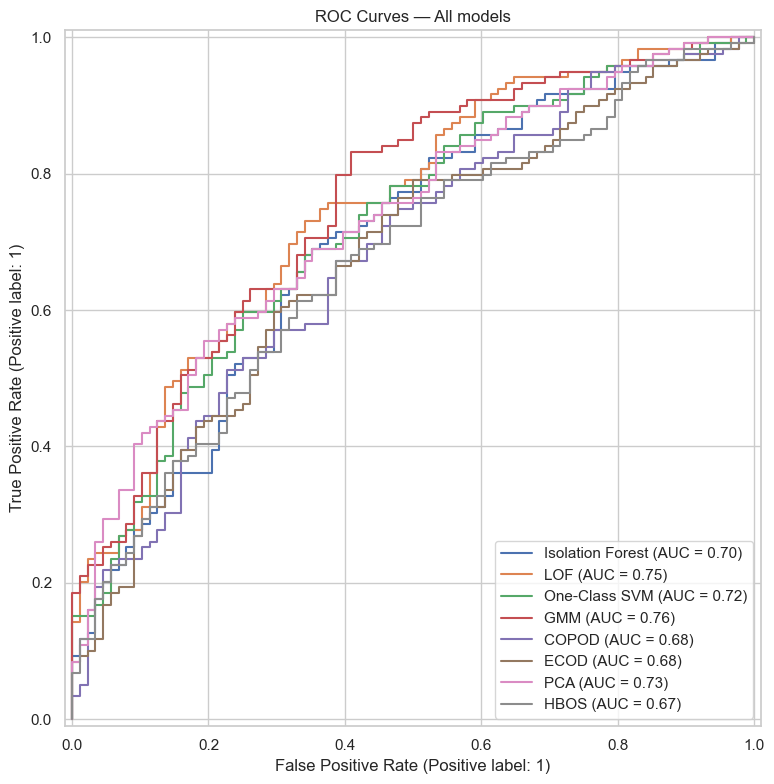

In [52]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

scores_dict = {
    'Isolation Forest': if_score,
    'LOF':              lof_score,
    'One-Class SVM':    ocsvm_score,
    'GMM':              gmm_test_score,
    'COPOD':            copod_score,
    'ECOD':             ecod_score,
    'PCA':              pca_score,
    'HBOS':             hbos_score,
}

for name, score in scores_dict.items():
    RocCurveDisplay.from_predictions(y_test, score, name=name, ax=ax)

ax.set_title('ROC Curves — All models')
plt.tight_layout()
plt.show()

### 7.2 Feature Importance — Permutation

Identifies which financial variables contribute most to anomaly detection
in the **LOF (Optuna)** model — the best-performing model in terms of AUC
among the optimized approaches.

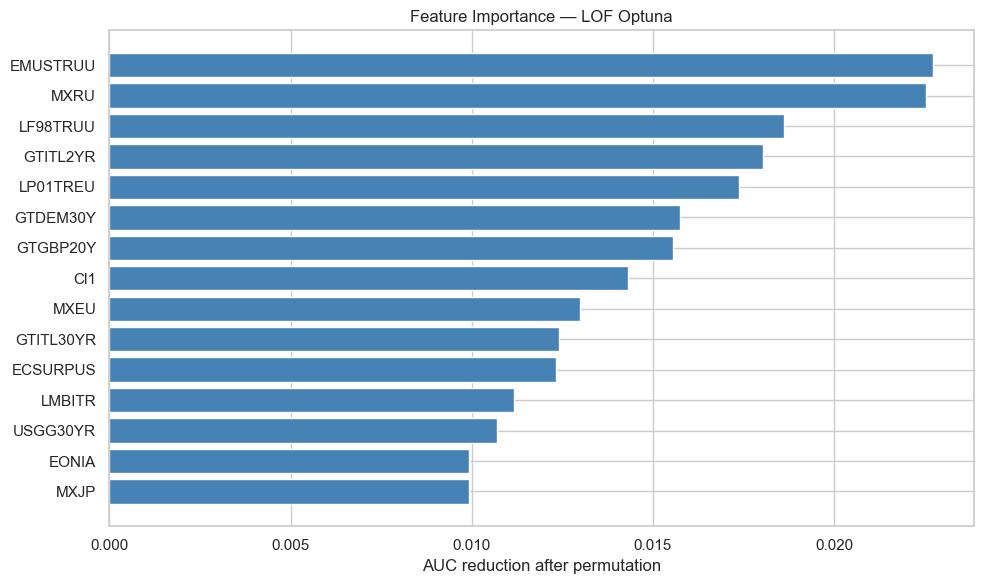

In [53]:
from sklearn.inspection import permutation_importance

# On best model — LOF Optuna
baseline_auc = roc_auc_score(y_test, lof_score)

importances = []
for i in range(X_test.shape[1]):
    X_test_permuted = X_test.copy()
    X_test_permuted[:, i] = np.random.permutation(X_test_permuted[:, i])
    score_perm = -best_lof.decision_function(X_test_permuted)
    auc_perm   = roc_auc_score(y_test, score_perm)
    importances.append(baseline_auc - auc_perm)

# bar chart
feat_names = stationary_df.columns.tolist()
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('AUC reduction after permutation')
plt.title('Feature Importance — LOF Optuna')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 7.3 Temporal Analysis — PCA Reconstruction

Applies the PCA Reconstruction model to the **entire dataset in chronological order**
(without shuffling) to visualize the evolution of anomaly scores over time.

Red regions indicate periods classified as true anomalies in the dataset,
corresponding to major historical crises such as the 2008 financial crisis,
the 2011 European sovereign debt crisis, and the 2020 COVID-19 market crash.

> This plot addresses the most important practical question:
> *would the model have detected historical crises in time?*

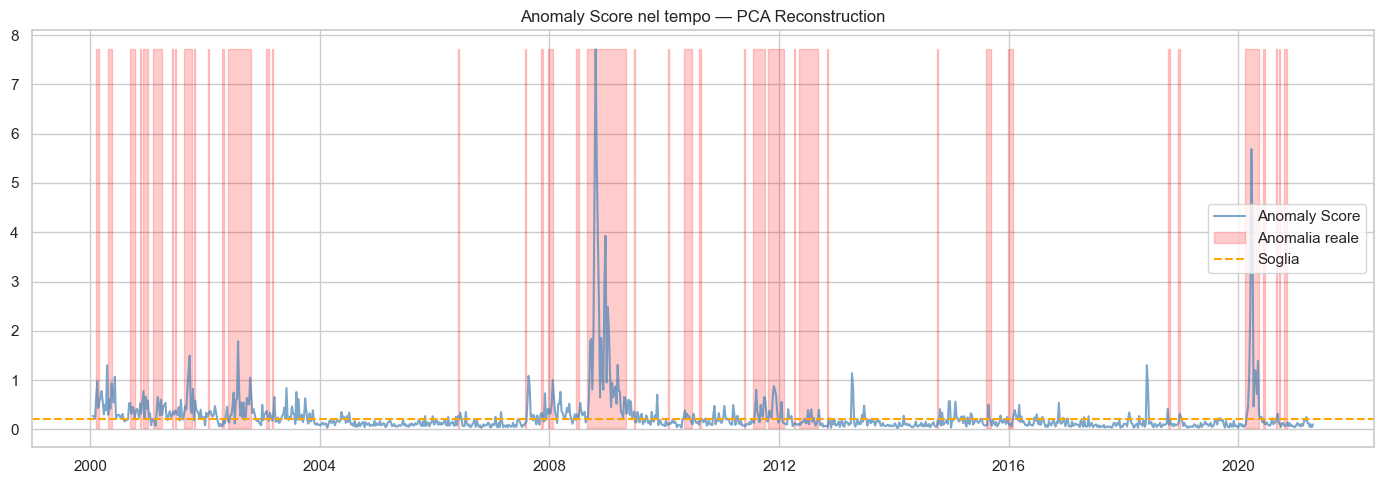

In [ ]:
pca_full_model = PCA(n_components=best_k, random_state=42)
pca_full_model.fit(X_train)

X_all_scaled = scaler.transform(stationary_df.values)
X_all_rec    = pca_full_model.inverse_transform(pca_full_model.transform(X_all_scaled))
all_scores   = np.mean((X_all_scaled - X_all_rec)**2, axis=1)
all_pred     = (all_scores > best_t).astype(int)

plt.figure(figsize=(14, 5))
plt.plot(stationary_df.index, all_scores, label='Anomaly Score', color='steelblue', alpha=0.7)
plt.fill_between(stationary_df.index,
                 all_scores.min(), all_scores.max(),
                 where=(y_stationary == 1),
                 alpha=0.2, color='red', label='Anomalia reale')
plt.axhline(best_t, color='orange', linestyle='--', label='Soglia')
plt.title('Anomaly Score nel tempo — PCA Reconstruction')
plt.legend()
plt.tight_layout()
plt.show()

### 7.4 Directional Filter — Symmetry Analysis of Boom vs. Crisis

Unsupervised anomaly detection models flag any deviation from normality,
regardless of direction. This includes coordinated market rallies (equities up,
VIX down, tight spreads), which are statistically unusual but do not necessarily
require a defensive response. This symmetry issue is formalized in Sornette (2009)
through the distinction between **Black Swans** (exogenous, unpredictable shocks)
and **Dragon Kings** (endogenous crises with detectable precursors in time series).

We implement a directional filter as a post-processing step on all model predictions:
for each observation classified as an anomaly, we compute its projection onto the
risk-off direction in the 42-dimensional feature space and suppress signals that
point in the opposite (risk-on) direction.

The risk-off direction is estimated as the normalized difference between the mean
of anomalies and the mean of normal observations in the cross-validation set,
without introducing additional tunable parameters.

In [ ]:
# Risk-off direction 
mean_normal  = X_cross_val[y_cross_val == 0].mean(axis=0)
mean_anomaly = X_cross_val[y_cross_val == 1].mean(axis=0)

risk_off_dd = mean_anomaly - mean_normal
risk_off_dd = risk_off_dd / np.linalg.norm(risk_off_dd)

# projections on CV and test
proj_cv_dd = X_cross_val @ risk_off_dd
proj_dd    = X_test      @ risk_off_dd

print("── Directional separation ───────────────────────────")
print(f"Normal   — mean projection: {proj_dd[y_test==0].mean():.3f}")
print(f"Anomalies — mean projection: {proj_dd[y_test==1].mean():.3f}")
print(f"Gap:                         {proj_dd[y_test==1].mean() - proj_dd[y_test==0].mean():.3f}")

# Filter function 
def apply_directional_filter(pred, projections, threshold=0.0):
    pred_filtered = pred.copy()
    pred_filtered[(pred == 1) & (projections <= threshold)] = 0
    return pred_filtered

# Conservative threshold: 5th percentile of real anomalies in CV 
conservative_thresh = np.percentile(proj_cv_dd[y_cross_val == 1], 5)
print(f"\nConservative threshold (5th pct CV anomalies): {conservative_thresh:.4f}")

# Apply filter to all models with both thresholds 
models_to_filter = {
    'Isolation Forest':          (iso_pred,   iso_score),
    'One-Class SVM':             (ocsvm_pred, ocsvm_score),
    'LOF':                       (lof_pred,   lof_score),
    'GMM 2 components':          (gmm_pred,   gmm_test_score),
    'COPOD':                     (copod_pred, copod_score),
    'ECOD':                      (ecod_pred,  ecod_score),
    'PCA Reconstruction':        (pca_pred,   pca_score),
    'HBOS':                      (hbos_pred,  hbos_score),
    'LOF (Optuna)':              (lof_pred,   lof_score),
    'Isolation Forest (Optuna)': (if_pred,    if_score),
    'One-Class SVM (Optuna)':    (ocsvm_pred, ocsvm_score),
}

print(f"\n{'─'*75}")
print(f"{'Model':30} {'F1 orig':>8} {'F1 t=0':>8} {'Δ t=0':>8} {'F1 cons':>8} {'Δ cons':>8}")
print(f"{'─'*75}")

delta_t0, delta_cons = [], []

for name, (pred, score) in models_to_filter.items():
    f1_orig = f1_score(y_test, pred, zero_division=0)

    pred_t0   = apply_directional_filter(pred, proj_dd, threshold=0.0)
    pred_cons = apply_directional_filter(pred, proj_dd, threshold=conservative_thresh)

    f1_t0   = f1_score(y_test, pred_t0,   zero_division=0)
    f1_cons = f1_score(y_test, pred_cons, zero_division=0)

    d_t0   = f1_t0   - f1_orig
    d_cons = f1_cons - f1_orig

    delta_t0.append(d_t0)
    delta_cons.append(d_cons)

    print(f"{name:30} {f1_orig:>8.4f} {f1_t0:>8.4f} {d_t0:>+8.4f} "
          f"{f1_cons:>8.4f} {d_cons:>+8.4f}")

print(f"{'─'*75}")
print(f"{'Average':30} {'':>8} {'':>8} {np.mean(delta_t0):>+8.4f} "
      f"{'':>8} {np.mean(delta_cons):>+8.4f}")

── Separazione direzionale ──────────────────────────
Normali  — proiezione media: -0.331
Anomalie — proiezione media: 2.634
Gap:                         2.965

Soglia conservativa (5° pct anomalie CV): -4.8749

───────────────────────────────────────────────────────────────────────────
Modello                         F1 orig   F1 t=0    Δ t=0  F1 cons   Δ cons
───────────────────────────────────────────────────────────────────────────
Isolation Forest                 0.7294   0.6373  -0.0922   0.7206  -0.0088
One-Class SVM                    0.7533   0.6870  -0.0664   0.7466  -0.0068
LOF                              0.7376   0.6377  -0.1000   0.7294  -0.0082
GMM 2 components                 0.6844   0.5543  -0.1301   0.6697  -0.0147
COPOD                            0.7120   0.6368  -0.0752   0.7025  -0.0095
ECOD                             0.6835   0.5864  -0.0972   0.6725  -0.0111
PCA Reconstruction               0.6844   0.5792  -0.1052   0.6728  -0.0116
HBOS                        

**Result:** the directional filter degrades F1 across all 11 models, regardless
of the threshold used.

| Threshold | Mean ΔF1 |
|---|---|
| Aggressive (t = 0.0) | -0.0919 |
| Conservative (t = -4.87) | -0.0094 |

The risk-off direction correctly separates normal observations from anomalies,
with a projection gap of **2.965** (normals: -0.331, anomalies: +2.634),
confirming that the financial signature of crises is consistent with expectations:
VIX up, equities down, gold up during risk-off regimes.

However, the filter does not improve performance because, in the 2000–2021 dataset,
coordinated bullish extremes are relatively rare compared to crisis periods. The
sample includes the dot-com crash (2001), the Global Financial Crisis (2008), the
European sovereign debt crisis (2011), the 2015 China slowdown, and the COVID-19
crash (2020) — all predominantly risk-off events. The number of false positives
corresponding to excessive risk-on rallies is too small in the test set to offset
the loss in recall introduced by the filter.

The most affected model under the aggressive threshold is **GMM** (ΔF1 = -0.1301),
which already suffers from low recall; the filter further amplifies missed
anomalies. The most robust model is **One-Class SVM (Optuna)** (ΔF1 = -0.0068 under
the conservative threshold), thanks to its high recall (0.95), which partially
absorbs the loss of true positives.

The directional filter would likely be more effective on datasets containing
extended bullish regimes such as 1995–1999 or 2017–2018, where statistical models
would generate more systematic false alarms in the risk-on direction.

This is an **informative negative result**: it confirms that classical unsupervised
models, on this dataset, are not significantly affected by the symmetry problem
identified in Sornette (2009).

## 8. Conclusions

### Key Findings

The tested models can be grouped into two main families with opposite trade-offs:

**High Recall, Low Precision** → LOF, Isolation Forest, One-Class SVM, HBOS  
These models capture most crises at the cost of more false alarms.  
They are preferable in **risk management** contexts, where missing a crisis
is more costly than triggering a false alarm.

**High Precision, Low Recall** → GMM, PCA Reconstruction  
When these models signal an anomaly, they are usually correct, but they miss
many crises. They are more suitable for **alpha generation** contexts, where
false signals are costly.

### Best Models by Metric

| Metric | Model | Value |
|---|---|---|
| F1 | One-Class SVM (Optuna) | 0.7533 |
| AUC | GMM (2 components) | 0.7552 |
| Recall | One-Class SVM (Optuna) | 0.9496 |
| Precision | PCA Reconstruction | 0.7264 |

**One-Class SVM (Optuna)** is the most suitable model for a risk management
system—it captures ~95% of real crises at the cost of lower precision (0.62).
In this context, the trade-off is acceptable: one additional false alarm is
preferable to missing a crisis.

**GMM** achieves the highest AUC (0.755), meaning its raw scores best separate
normal from anomalous regimes. However, the fixed threshold derived from the
contamination parameter does not fully exploit this signal. With more refined
threshold tuning, it could become the best model in terms of F1.

### Effect of Optuna Optimization

Optuna improves baseline performance across all three optimized models when the
contamination is set to the true dataset level (~21%) instead of the artificially
inflated CV level (50%). This confirms that contamination is the most critical
hyperparameter in unsupervised anomaly detection—more important than structural
model parameters.

### Directional Filter

The Sornette-inspired directional filter—which suppresses anomaly signals in the
risk-on direction to reduce false alarms during rallies—does not improve performance
on this dataset (mean ΔF1 = -0.0094 under the conservative threshold). While a clear
directional signature exists (projection gap: 2.965), false positives during risk-on
rallies are too infrequent in the 2000–2021 period to compensate for the loss in recall.
The filter would likely be more effective in datasets containing prolonged bull markets
such as 1995–1999 or 2017–2018.

### Pros & Cons Table

| Model | Decision Boundary | Labels needed | Contamination needed | Pros | Cons |
|---|---|---|---|---|---|
| Isolation Forest | Non-linear (tree-based) | No | Yes | Fast, scalable | Weak in low dimensions |
| One-Class SVM | Non-linear (kernel-based) | No | Yes | Flexible, expressive | Slow, sensitive to gamma |
| LOF | Local density-based | No | Yes | Detects local anomalies | Poor in high dimensions |
| GMM | Probabilistic (ellipsoids) | No | No | Best AUC, captures regimes | Assumes Gaussianity |
| COPOD | Non-parametric (copulas) | No | Yes | Robust to fat tails | Assumes tail independence |
| ECOD | Non-parametric (ECDF) | No | Yes | Very fast, recent approach | Ignores feature dependencies |
| PCA | Linear subspace | No | No | Interpretable, financially motivated | Assumes linear structure |
| HBOS | Feature-wise histograms | No | Yes | Extremely simple and fast | Ignores dependencies |